In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample 
import utils as u

# Load orography Datasets

### MAR

In [34]:
sourceDataGrid='/home/amoryc/'

#Fedchenko
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF_Fed= xr.open_dataset(sourceDataGrid+fileName_grF).SH

#Mera
fileName_grF='NST.2000.01.01.00.GRa.nc'
ds_grF_Mera= xr.open_dataset(sourceDataGrid+fileName_grF).SH

### ERA5-land

(61, 121)


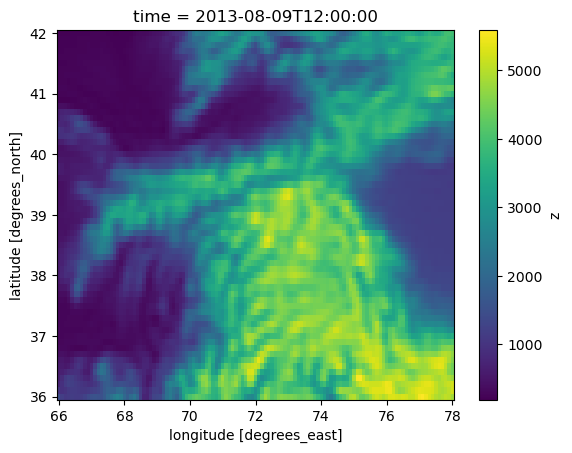

In [30]:
# Fedchenko
orog_era5land_Fed= xr.open_dataset(folder_era5land + 'geo.area-subset.42.78.36.66.nc').z.isel(time=0).load()/9.80665
print(orog_era5land_Fed.shape)
orog_era5land_Fed[:,:].plot()

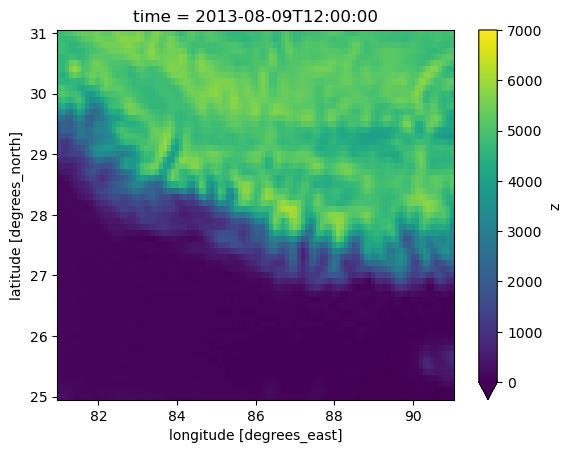

In [33]:
# Mera
orog_era5land_Mera= xr.open_dataset(folder_era5land + 'geo.area-subset.31.91.25.81.nc').z.isel(time=0).load()/9.80665
orog_era5land_Mera[:,:].plot(vmin=0, vmax=7000)

### ERA5

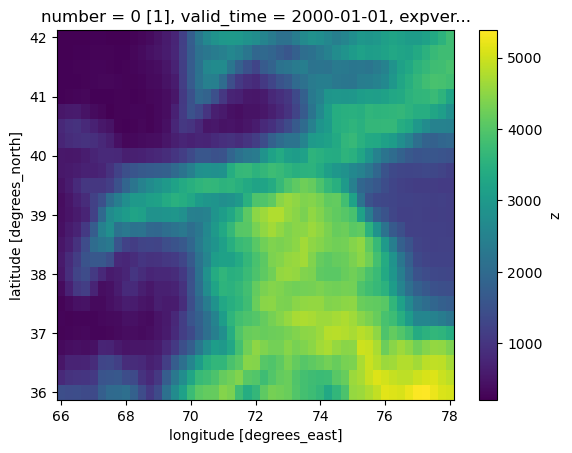

In [32]:
# Fedchenko
orog_era5_Fed = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5_Fed[:,:].plot()

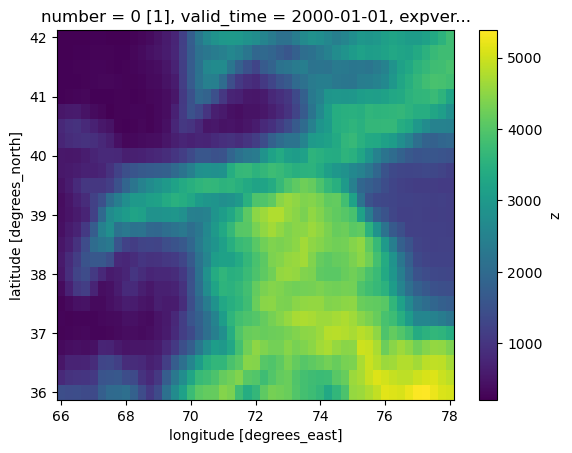

In [35]:
# Mera
orog_era5_Mera = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5_Mera[:,:].plot()

# Fedchenko 

In [19]:
alt_mar_Fed = ds_grF_Fed.values.flatten()
alt_era5_land_Fed = orog_era5land_Fed.values.flatten()
alt_era5_Fed = orog_era5_Fed.values.flatten()

data = [alt_mar_Fed, alt_era5_Fed, alt_era5_land_Fed]
titles = ['MAR', 'ERA5', 'ERA5-Land']

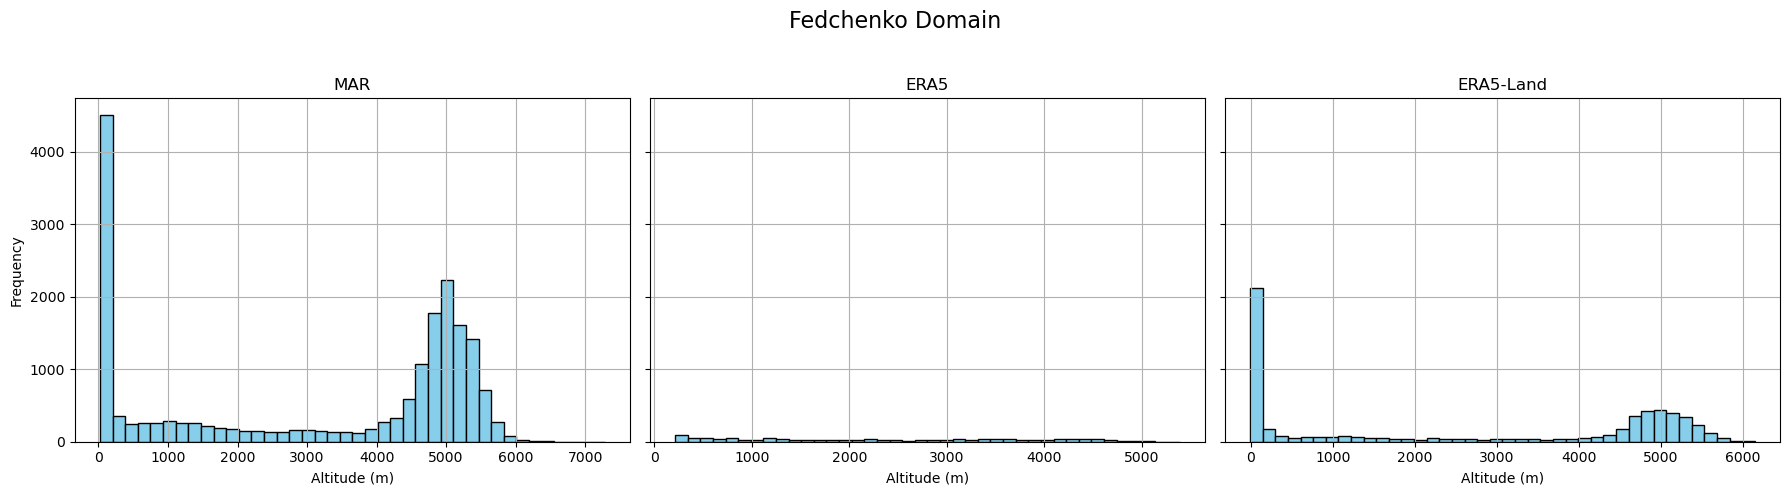

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i in range(3):
    axes[i].hist(data[i], bins=40, color='skyblue', edgecolor='black')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Altitude (m)')
    if i == 0:
        axes[i].set_ylabel('Frequency')
    axes[i].grid(True)


fig.suptitle('Fedchenko Domain', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Laisse de la place pour le titre
plt.show()

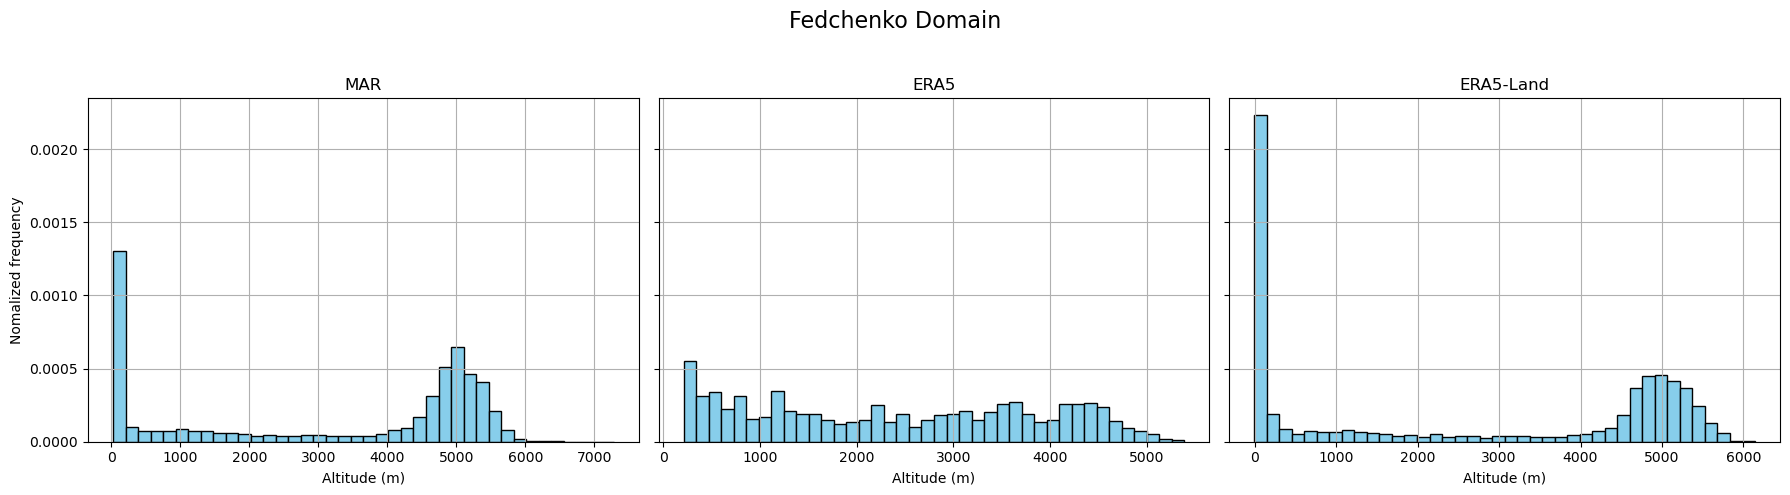

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i in range(3):
    axes[i].hist(data[i], bins=40, density=True, color='skyblue', edgecolor='black')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Altitude (m)')
    if i == 0:
        axes[i].set_ylabel('Nomalized frequency')
    axes[i].grid(True)


fig.suptitle('Fedchenko Domain', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Laisse de la place pour le titre
plt.show()

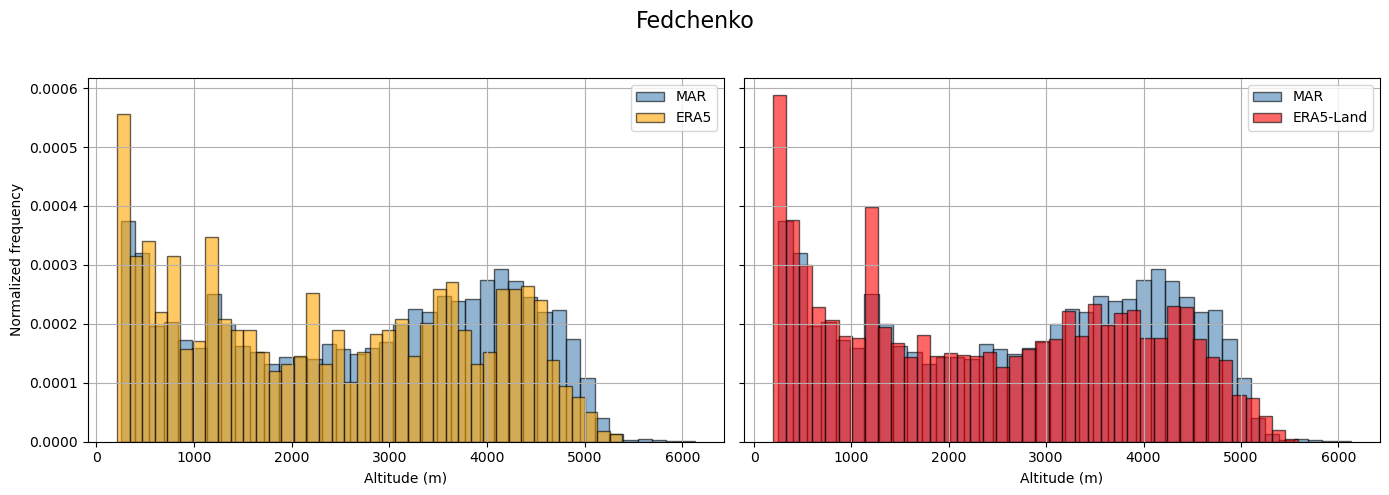

<Figure size 640x480 with 0 Axes>

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(alt_mar, bins=40, density=True, alpha=0.6, label='MAR', color='steelblue', edgecolor='black')
axes[0].hist(alt_era5, bins=40, density=True, alpha=0.6, label='ERA5', color='orange', edgecolor='black')
# axes[0].set_title('Zone 1 vs Zone 2')
axes[0].set_xlabel('Altitude (m)')
axes[0].set_ylabel('Normalized frequency')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(alt_mar, bins=40, density=True, alpha=0.6, label='MAR', color='steelblue', edgecolor='black')
axes[1].hist(alt_era5_land, bins=40, density=True, alpha=0.6, label='ERA5-Land', color='red', edgecolor='black')
# axes[1].set_title('Zone 3 vs Zone 4')
axes[1].set_xlabel('Altitude (m)')
axes[1].legend()
axes[1].grid(True)

fig.suptitle('Fedchenko', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.savefig("Orog_Distrib_Fed.png", dpi=200, bbox_inches='tight')

# Mera 

In [37]:
alt_mar_Mera = ds_grF_Mera.values.flatten()
alt_era5_land_Mera = orog_era5land_Mera.values.flatten()
alt_era5_Mera = orog_era5_Mera.values.flatten()

titles = ['MAR', 'ERA5', 'ERA5-Land']
data = [alt_mar_Mera, alt_era5_Mera, alt_era5_land_Mera]

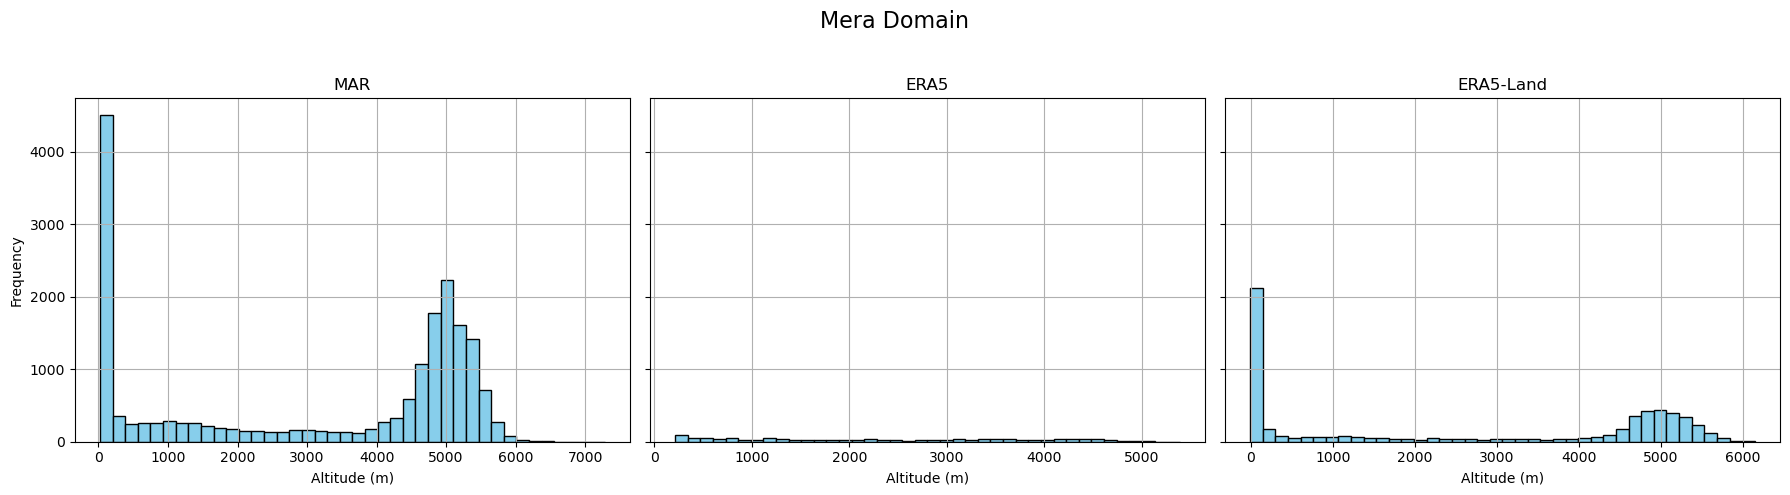

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i in range(3):
    axes[i].hist(data[i], bins=40, color='skyblue', edgecolor='black')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Altitude (m)')
    if i == 0:
        axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

fig.suptitle('Mera Domain', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Laisse de la place pour le titre
plt.show()

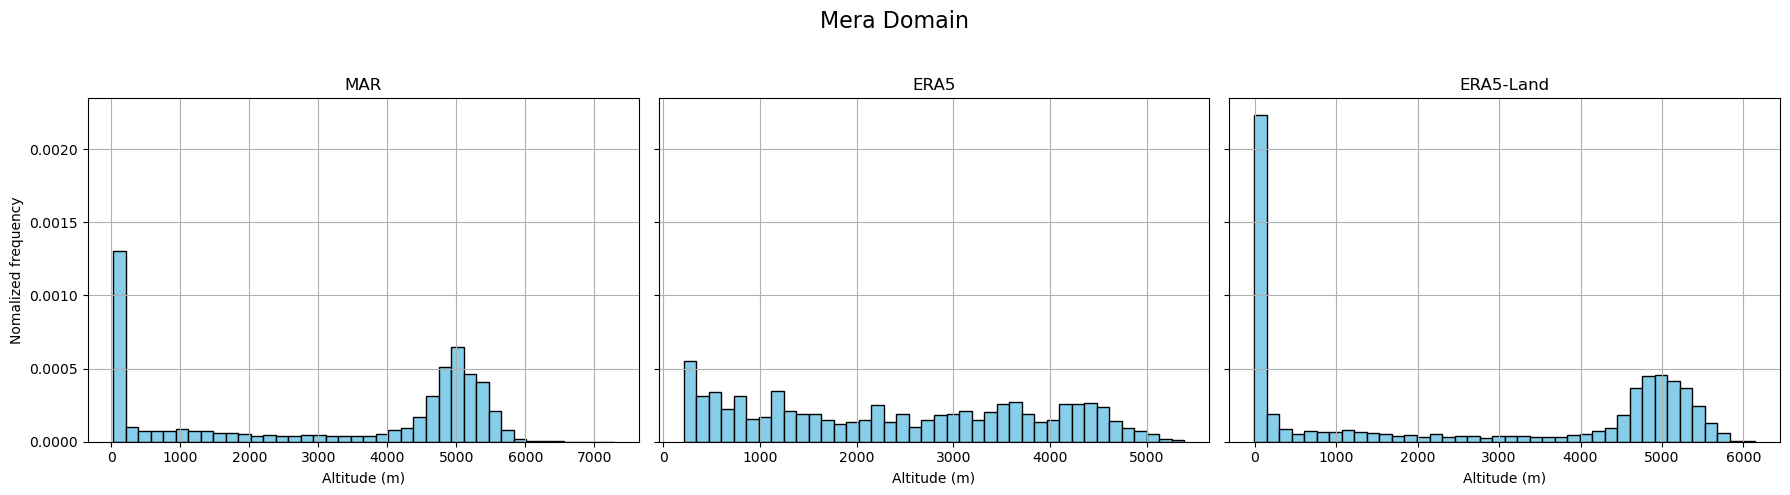

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i in range(3):
    axes[i].hist(data[i], bins=40, density=True, color='skyblue', edgecolor='black')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Altitude (m)')
    if i == 0:
        axes[i].set_ylabel('Nomalized frequency')
    axes[i].grid(True)

fig.suptitle('Mera Domain', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Laisse de la place pour le titre
plt.show()

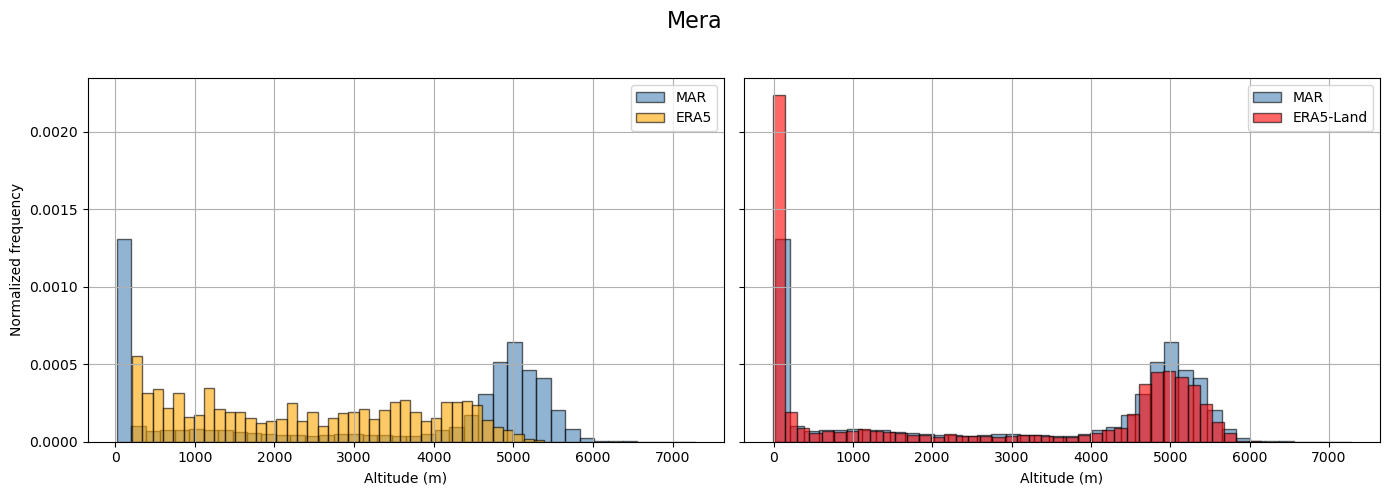

<Figure size 640x480 with 0 Axes>

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(alt_mar_Mera, bins=40, density=True, alpha=0.6, label='MAR', color='steelblue', edgecolor='black')
axes[0].hist(alt_era5_Mera, bins=40, density=True, alpha=0.6, label='ERA5', color='orange', edgecolor='black')
# axes[0].set_title('Zone 1 vs Zone 2')
axes[0].set_xlabel('Altitude (m)')
axes[0].set_ylabel('Normalized frequency')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(alt_mar_Mera, bins=40, density=True, alpha=0.6, label='MAR', color='steelblue', edgecolor='black')
axes[1].hist(alt_era5_land_Mera, bins=40, density=True, alpha=0.6, label='ERA5-Land', color='red', edgecolor='black')
# axes[1].set_title('Zone 3 vs Zone 4')
axes[1].set_xlabel('Altitude (m)')
axes[1].legend()
axes[1].grid(True)

fig.suptitle('Mera', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.savefig("Orog_Distrib_Mera.png", dpi=200, bbox_inches='tight')